In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df = df[df['job_title_short']== 'Data Analyst']

In [7]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg','median')
)

In [8]:
skill_stats = skill_stats.sort_values('skill_count', ascending=False).head(10)

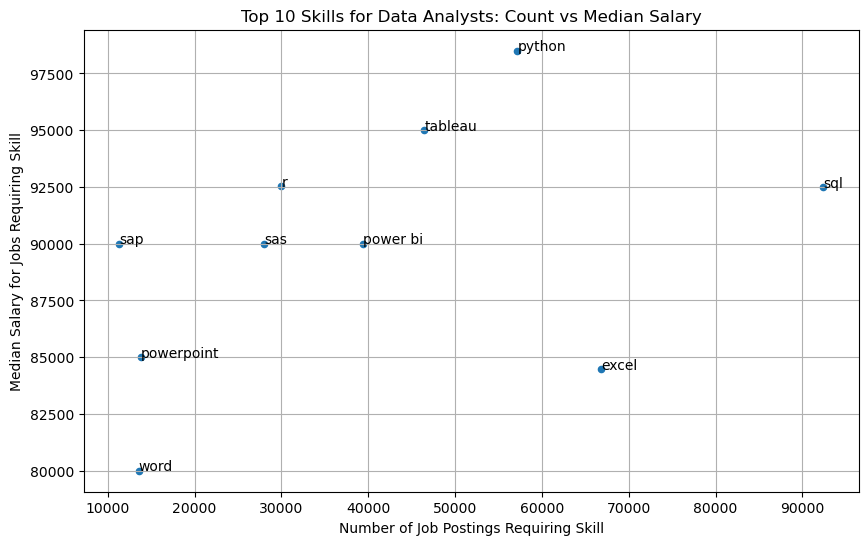

In [10]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary', figsize=(10, 6))
plt.title('Top 10 Skills for Data Analysts: Count vs Median Salary')    
plt.xlabel('Number of Job Postings Requiring Skill')
plt.ylabel('Median Salary for Jobs Requiring Skill')
plt.grid(True)

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i],txt)
plt.show()

In [12]:
from adjustText import adjust_text  

ModuleNotFoundError: No module named 'adjustText'